<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab2/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
tickers = ["WMT", "SBUX", "NVDA", "^GSPC"]
stocks = yf.download(tickers, start="2019-01-01")

/tmp/ipykernel_5549/557824686.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(tickers, start="2019-01-01")
[*********************100%***********************]  4 of 4 completed


In [3]:
stocks.head()

Price          Close                                         High             \
Ticker          NVDA       SBUX        WMT        ^GSPC      NVDA       SBUX   
Date                                                                           
2019-01-02  3.373052  54.597130  27.913778  2510.030029  3.429013  54.639574   
2019-01-03  3.169262  52.228886  27.770231  2447.889893  3.346804  54.087839   
2019-01-04  3.372310  53.960495  27.943678  2531.939941  3.410443  54.537704   
2019-01-07  3.550843  53.960495  28.272644  2549.689941  3.587738  54.529213   
2019-01-08  3.462442  54.002934  28.470020  2574.409912  3.634537  54.571655   

Price                                    Low                        \
Ticker            WMT        ^GSPC      NVDA       SBUX        WMT   
Date                                                                 
2019-01-02  28.006486  2519.489990  3.220271  53.654921  27.405386   
2019-01-03  28.323483  2493.139893  3.161834  52.118539  27.722383   
2019-01-04  28.009469  2538.070068  3.211606  52.695731  27.719387   
2019-01-07  28.461049  2566.159912  3.378253  53.255963  27.865930   
2019-01-08  28.637491  2579.820068  3.389890  53.519097  28.084239   

Price                        Open                                     \
Ticker            ^GSPC      NVDA       SBUX        WMT        ^GSPC   
Date                                                                   
2019-01-02  2467.469971  3.234881  54.053875  27.405386  2476.959961   
2019-01-03  2443.959961  3.312881  53.867140  27.874901  2491.919922   
2019-01-04  2474.330078  3.242310  52.967359  27.874894  2474.330078   
2019-01-07  2524.560059  3.429510  53.773750  27.997515  2535.610107   
2019-01-08  2547.560059  3.632308  54.274561  28.428152  2568.110107   

Price          Volume                                  
Ticker           NVDA      SBUX       WMT       ^GSPC  
Date                                                   
2019-01-02  508752000  10094000  24458100  3733160000  
2019-01-03  705552000  14390100  24831900  3858830000  
2019-01-04  585620000  12694400  24087300  4234140000  
2019-01-07  709160000  10337600  23369100  4133120000  
2019-01-08  786016000  10809700  21602700  4120060000

In [4]:
print(stocks.columns)

MultiIndex([( 'Close',  'NVDA'),
            ( 'Close',  'SBUX'),
            ( 'Close',   'WMT'),
            ( 'Close', '^GSPC'),
            (  'High',  'NVDA'),
            (  'High',  'SBUX'),
            (  'High',   'WMT'),
            (  'High', '^GSPC'),
            (   'Low',  'NVDA'),
            (   'Low',  'SBUX'),
            (   'Low',   'WMT'),
            (   'Low', '^GSPC'),
            (  'Open',  'NVDA'),
            (  'Open',  'SBUX'),
            (  'Open',   'WMT'),
            (  'Open', '^GSPC'),
            ('Volume',  'NVDA'),
            ('Volume',  'SBUX'),
            ('Volume',   'WMT'),
            ('Volume', '^GSPC')],
           names=['Price', 'Ticker'])


In [4]:
# Seleccionar 'Close' (que ya contiene el precio ajustado por defecto)
precios_ajustados = stocks['Close']

print(precios_ajustados.head())

Ticker          NVDA       SBUX        WMT        ^GSPC
Date                                                   
2019-01-02  3.373051  54.597126  27.913771  2510.030029
2019-01-03  3.169262  52.228863  27.770233  2447.889893
2019-01-04  3.372309  53.960499  27.943684  2531.939941
2019-01-07  3.550842  53.960499  28.272646  2549.689941
2019-01-08  3.462442  54.002941  28.470020  2574.409912


# Pregunta

Construye un gráfico de líneas

# Pregunta


Calcula los retornos diarios a partir de los precios ajustados, usando la siguiente fórmula:

$$r_t=\frac{P_t-P_{t-1}}{P_{t-1}}\times 100$$

In [5]:
retornos_diarios = precios_ajustados.pct_change().dropna()*100

/tmp/ipykernel_5549/1361331687.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos_diarios = precios_ajustados.pct_change().dropna()*100


# Pregunta

Calcula la estadística descriptiva de los retornos diarios

In [13]:
retornos_diarios.describe().style.format("{:.2f}%")

Ticker,NVDA,SBUX,WMT,^GSPC
count,1875.00%,1875.00%,1875.00%,1875.00%
mean,0.27%,0.05%,0.09%,0.07%
std,3.20%,2.03%,1.40%,1.24%
min,-18.45%,-16.20%,-11.38%,-11.98%
25%,-1.49%,-0.90%,-0.58%,-0.43%
50%,0.31%,0.04%,0.09%,0.10%
75%,1.98%,0.93%,0.75%,0.67%
max,24.37%,24.50%,11.71%,9.52%


# Pregunta

Construye un histograma de los retornos diarios de las acciones y del S&P500.

In [7]:
# Transformar los datos de wide format a long format para Seaborn
retornos_largos = retornos_diarios.melt(var_name='Activo', value_name='Retorno Diario (%)')
retornos_largos

,Activo,Retorno Diario (%)
0,NVDA,-6.041674
1,NVDA,6.406760
2,NVDA,5.294082
3,NVDA,-2.489567
4,NVDA,1.966682
...,...,...
7495,^GSPC,0.502551
7496,^GSPC,1.652839
7497,^GSPC,-0.568418
7498,^GSPC,-1.214828


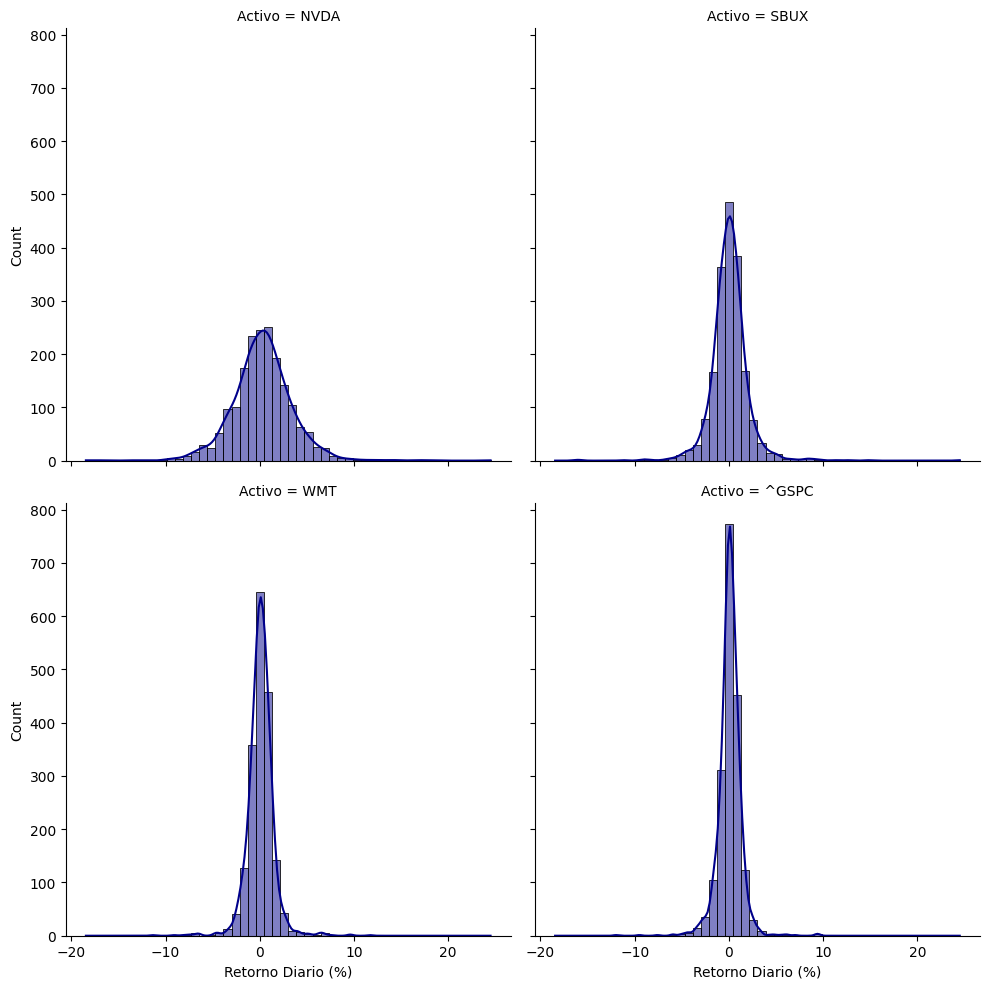

In [17]:
# Graficar los histogramas en columnas separadas
sns.displot(
    data=retornos_largos,
    x="Retorno Diario (%)",
    col="Activo",       # Crea una columna por cada ticker
    col_wrap=2,         # Rompe la fila cada 2 gráficos (crea una matriz de 2x2)
    kde=True,           # Agrega la línea de estimación de densidad (curva suavizada)
    bins=50,            # Define la cantidad de barras
    color="darkblue"
)

# Pregunta

Calcula la matriz de correlación ¿Qué acción tiene la mayor correlación con el S&P500?

In [14]:
retornos_diarios.corr()

Ticker,NVDA,SBUX,WMT,^GSPC
Ticker,,,,
NVDA,1.000000,0.379728,0.205576,0.700344
SBUX,0.379728,1.000000,0.267858,0.630866
WMT,0.205576,0.267858,1.000000,0.413119
^GSPC,0.700344,0.630866,0.413119,1.000000


# Pregunta


In [7]:
precios_mensuales = precios_ajustados.resample('ME').last()
precios_mensuales

Ticker,NVDA,SBUX,WMT,^GSPC
Date,,,,
2019-01-31,3.559508,57.839684,28.658421,2704.100098
2019-02-28,3.823692,59.950485,29.603439,2784.489990
2019-03-31,4.450811,63.431789,29.323755,2834.399902
2019-04-30,4.486506,66.281700,30.920275,2945.830078
2019-05-31,3.361523,65.200485,30.661367,2752.060059
...,...,...,...,...
2026-02-28,176.974152,97.448830,127.444725,6878.879883
2026-03-31,174.196976,89.067947,124.043274,6528.520020
2026-04-30,199.337677,104.716240,131.678696,7209.009766


In [8]:
retornos_mensuales = precios_mensuales.pct_change().dropna()
retornos_mensuales

Ticker,NVDA,SBUX,WMT,^GSPC
Date,,,,
2019-02-28,0.074219,0.036494,0.032975,0.029729
2019-03-31,0.164009,0.058070,-0.009448,0.017924
2019-04-30,0.008020,0.044929,0.054445,0.039313
2019-05-31,-0.250748,-0.016312,-0.008373,-0.065778
2019-06-30,0.212387,0.102156,0.089215,0.068930
...,...,...,...,...
2026-02-28,-0.072935,0.072889,0.073947,-0.008668
2026-03-31,-0.015693,-0.086003,-0.026690,-0.050933
2026-04-30,0.144323,0.175689,0.061555,0.104233
